In [2]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
import camb
import cosmoprimo
import os
# from scipy.stats import linregress
# from scipy.optimize import curve_fit

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# looking at distances values on degeneracy line

In [3]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\run1'
gd_sample = load_samples(path, to_getdist=True, skip=0.33)
var_names = ['hrdrag', 'omm', 'w', 'wa']
# gdplot = gdplt.get_subplot_plotter()
# gdplot.triangle_plot(gd_sample, var_names, filled=True)

#### definitions

In [4]:
def expansion_rate(z, Omega_m, Omega_Lambda, w0=-1.0, wa=0): # by default lambdaCDM
    """    
    Parameters:
    z Redshift
    Omega_m Matter density parameter
    Omega_Lambda DE density parameter
    w0 constant equation of state parameter for DE
    wa varying equation of state parameter for DE

    Returns: E(z) = H(z)/H0
    """
    Omega_DE = Omega_Lambda * (1 + z)**(3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))

    Omega_total = Omega_m * (1 + z)**3 + Omega_DE

    E_z = np.sqrt(Omega_total)
    return E_z

def trans_comoving_dist_array(z, par):
    """
    Returns: Transverse comoving distance D_M(z) in units of h^-1 Mpc
    """
    c = 299792.458  # km/s
    from scipy.integrate import quad

    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe

    def integrand(z_prime):
        return 1 / expansion_rate(z_prime, Omega_m, Omega_Lambda, w0, wa)

    # check if z is a scalar or an array
    if np.isscalar(z):
        integral, _ = quad(integrand, 0, z)
        return c/100 * integral
    
    integral1, _ = quad(integrand, 0, z[0])
    integrals = []
    for i in range(len(z)):
        part_int = quad(integrand, z[i-1], z[i])[0] if i > 0 else integral1
        integrals.append(part_int + (integrals[i-1] if i > 0 else 0))
    return [c/100 * el for el in integrals]

def Hubble_dist(z, par):# Omega_m, Omega_Lambda, w0=-1.0, wa=0):
    """
    Returns: Hubble distance D_H(z) in units of h^-1 Mpc
    """
    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe
    c = 299792.458  # km/s
    return c/100 / expansion_rate(z, Omega_m, Omega_Lambda, w0, wa)

def compute_DV(z, par):
    '''
    Returns D_V(z) in units of h^-1 Mpc, D_V = (z * D_M^2(z) * D_H(z))^(1/3)
    '''
    DM = trans_comoving_dist_array(z, par)
    DH = Hubble_dist(z, par)
    return (z * DM**2 * DH)**(1/3)

### degeneracy lines 

In [5]:
gd_sample = load_samples(r'..\..\cobaya_runs\DESI_data\base_w_wa\run1', to_getdist=True, skip=0.33) # DESI all z run using w0waCDM

var_names = ['w', 'wa']

In [6]:
# gdplot = gdplt.get_single_plotter()
# gdplot.settings.axes_labelsize = 18
# gdplot.settings.axes_fontsize = 14
# gdplot.plot_2d(gd_sample, var_names[0], var_names[1], filled=True)
# # plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1, alpha=0.5, color='r')

# x_fit = np.linspace(-2, 1, 100)

# # plt.plot(x_fit, y_fit, color='r', ls=':', label='CMB+BAO')
# y_fit = -3.66 * (x_fit + 1)
# plt.plot(x_fit, y_fit, color='r', ls='-.', label=r'Mirage line $\simeq -3.66 (w_0 + 1)$')
# y_fit = 3.66 * (x_fit + 1)
# plt.plot(x_fit, y_fit, color='r', ls='--', label=r'$\perp$ to Mirage line')
# y_fit = -3.66 * (x_fit + 0.5)
# plt.plot(x_fit, y_fit, color='r', ls='-', label=r'$\parallel$ to Mirage line')

# y_fit = -x_fit
# plt.fill_between(x_fit, y_fit, 2, color='g', alpha=0.3, label=r'$w_0+w_a > 0$')
# # plt.plot(x_fit, y_fit, color='g', ls='-', label=r'$w_0+w_a < 0$')

# plt.axhline(0, color='k', ls='-')
# plt.axvline(-1, color='k', ls='-')

# plt.xlim(-1.1, 1.0)
# plt.ylim(-3, 2.0)
# plt.legend()


# # print("degeneracy line : wa =", round(slope, 1), "* w0 +", round(intercept, 1))

In [7]:
pathCMB_LCDM = r'..\..\DESI_DR2_chains\base\desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE\chain'
pathCMB = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE\chain'
# path3 = r'..\..\DESI_DR2_chains\base\desy5sn\chain'
pathUnion = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'
pathPantheon = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'
pathDESY5 = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'

gd_sampleCMB = load_samples(pathCMB, to_getdist=True, skip=0.33)
# gd_sample3 = load_samples(path3, to_getdist=True, skip=0.33)
gd_sampleUnion = load_samples(pathUnion, to_getdist=True, skip=0.33)
gd_samplePantheon = load_samples(pathPantheon, to_getdist=True, skip=0.33)
gd_sampleDESY5 = load_samples(pathDESY5, to_getdist=True, skip=0.33)

In [8]:
gd_sample_all = [gd_sampleCMB, gd_sampleUnion, gd_samplePantheon, gd_sampleDESY5]
gd_sample_all = [gd_sampleUnion, gd_samplePantheon, gd_sampleDESY5, gd_sampleCMB]

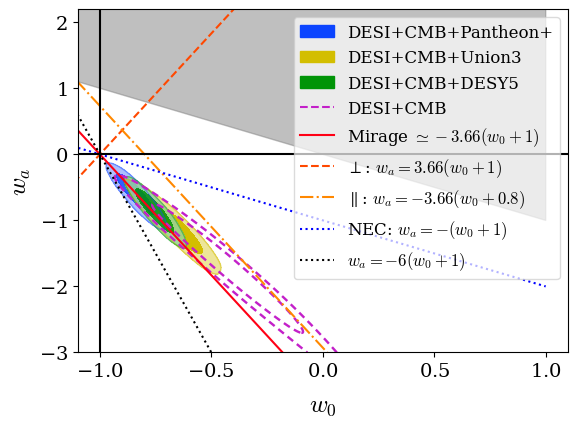

In [9]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#d3be00', '#0b44ff', '#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

gdplot.plot_2d(gd_sample_all, 'w', 'wa',
    filled=[True, True, True, False],
    line_args=[
        {'color': contour_colors[0]},
        {'color': contour_colors[1]},
        {'color': contour_colors[2]},
        {'color': contour_colors[3], 'ls': '--'},
    ]
)

ax = gdplot.get_axes()

x_fit = np.linspace(-2, 1, 100)

c_mirage = "#FF0015"
c_perp   = "#FF4800"
c_para   = "#FF8800"
c_nec    = 'b'
c_steep  = 'k'

ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

legend_handles = [
    mpatches.Patch(color=contour_colors[1], label='DESI+CMB+Pantheon+'),
    mpatches.Patch(color=contour_colors[0], label='DESI+CMB+Union3'),
    mpatches.Patch(color=contour_colors[2], label='DESI+CMB+DESY5'),
    mlines.Line2D([], [], color=contour_colors[3], ls='--',
                  label=r'DESI+CMB'),
    mlines.Line2D([], [], color=c_mirage, ls='-',
                  label=r'Mirage $\simeq -3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_perp,   ls='--',
                  label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_para,   ls='-.',
                  label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
    mlines.Line2D([], [], color=c_nec,    ls=':',
                  label=r'NEC: $w_a = -(w_0+1)$'),
    mlines.Line2D([], [], color=c_steep,  ls=':',
                  label=r'$w_a = -6(w_0+1)$')#,
]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-3, 2.2)

fig = gdplot.fig
# fig.savefig(r'..\..\figures\degen_line\w_wa_contour.png', dpi=300)

In [10]:
gd_sample_all = [gd_sampleDESY5, gd_sampleCMB]

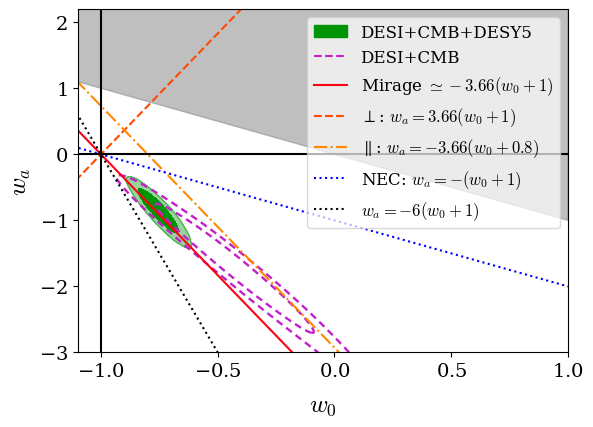

In [11]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

gdplot.plot_2d(gd_sample_all, 'w', 'wa',
    filled=[True, False],
    line_args=[
        {'color': contour_colors[0]},
        {'color': contour_colors[1], 'ls': '--'}
    ]
)

ax = gdplot.get_axes()

x_fit = np.linspace(-2, 1, 100)

c_mirage = "#FF0015"
c_perp   = "#FF4800"
c_para   = "#FF8800"
c_nec    = 'b'
c_steep  = 'k'

ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

legend_handles = [
    mpatches.Patch(color=contour_colors[0], label='DESI+CMB+DESY5'),
    mlines.Line2D([], [], color=contour_colors[1], ls='--',
                  label=r'DESI+CMB'),
    mlines.Line2D([], [], color=c_mirage, ls='-',
                  label=r'Mirage $\simeq -3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_perp,   ls='--',
                  label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_para,   ls='-.',
                  label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
    mlines.Line2D([], [], color=c_nec,    ls=':',
                  label=r'NEC: $w_a = -(w_0+1)$'),
    mlines.Line2D([], [], color=c_steep,  ls=':',
                  label=r'$w_a = -6(w_0+1)$')#,
]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.1, 1.0)
ax.set_ylim(-3, 2.2)

fig = gdplot.fig
# fig.savefig(r'..\..\figures\degen_line\w_wa_contour.png', dpi=300)

In [12]:
gd_sample_all = [gd_sampleCMB, gd_sampleDESY5]

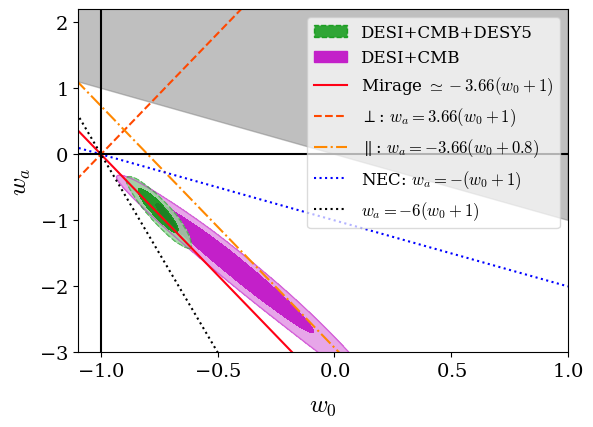

In [13]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

gdplot.plot_2d(gd_sample_all, 'w', 'wa',
    filled=[True, True],
    line_args=[
        {'color': contour_colors[1]},
        {'color': contour_colors[0], 'ls': '--'}
    ]
)

ax = gdplot.get_axes()

x_fit = np.linspace(-2, 1, 100)

c_mirage = "#FF0015"
c_perp   = "#FF4800"
c_para   = "#FF8800"
c_nec    = 'b'
c_steep  = 'k'

ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

legend_handles = [
    mpatches.Patch(color=contour_colors[0], label='DESI+CMB+DESY5', linestyle='--', alpha=0.8),
    mpatches.Patch(color=contour_colors[1], label='DESI+CMB'),
    mlines.Line2D([], [], color=c_mirage, ls='-',
                  label=r'Mirage $\simeq -3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_perp,   ls='--',
                  label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
    mlines.Line2D([], [], color=c_para,   ls='-.',
                  label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
    mlines.Line2D([], [], color=c_nec,    ls=':',
                  label=r'NEC: $w_a = -(w_0+1)$'),
    mlines.Line2D([], [], color=c_steep,  ls=':',
                  label=r'$w_a = -6(w_0+1)$')#,
]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.1, 1.0)
ax.set_ylim(-3, 2.2)

fig = gdplot.fig
# fig.savefig(r'..\..\figures\degen_line\w_wa_contour_cmb_desy5.png', dpi=300)

### cosmoprimo $\alpha_\perp, \ \alpha_\parallel$

In [14]:
def alpha_perp_parallel(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> the DESI fiducial cosmology
    '''

    w0, wa, Omega_m, hrdrag = cosmo_params

    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(z)
    DH_fid = 1 / DESI_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    custom_cosmo = cosmoprimo.Cosmology(w=w0, wa=wa, Omega_m=Omega_m)
    custom_bkg = custom_cosmo.get_background(engine='camb')
    DM_real = custom_bkg.comoving_angular_distance(z)
    DH_real = 1 / custom_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid

In [15]:
def get_Om_hrdrag(w0, wa):
    '''
    For each (w0, wa) pair, uses CAMB to get Omega_m, h*rdrag, h
    by fixing theta_star=0.01041, omega_b=0.02223, omega_bc=0.14208
    Dark energy initialized first, H0 set to None.
    
    Accepts scalars or lists/arrays for w0, wa.
    Returns Omega_m, hrdrag, h (arrays if input is array)
    '''

    scalar_input = np.ndim(w0) == 0
    w0 = np.atleast_1d(w0)
    wa = np.atleast_1d(wa)

    Omega_m_list = []
    hrdrag_list = []
    h_list = []

    for w0_i, wa_i in zip(w0, wa):
        pars = camb.CAMBparams()
        
        # Initialize dark energy first
        pars.set_dark_energy(w=w0_i, wa=wa_i, dark_energy_model='ppf')
        
        pars.set_cosmology(
            thetastar=0.01041,
            ombh2=0.02223,
            omch2=0.14208-0.02223,
            H0=None
        )

        results = camb.get_background(pars)
        
        h = pars.h
        Omega_m = pars.omegam
        rdrag = results.get_derived_params()['rdrag']
        hrdrag = h * rdrag

        Omega_m_list.append(Omega_m)
        hrdrag_list.append(hrdrag)
        h_list.append(h)

    Omega_m_arr = np.array(Omega_m_list)
    hrdrag_arr = np.array(hrdrag_list)
    h_arr = np.array(h_list)

    if scalar_input:
        return Omega_m_arr[0], hrdrag_arr[0], h_arr[0]
    
    return Omega_m_arr, hrdrag_arr, h_arr

### gradient of $w_0$ on Mirage line and other lines

#### test

In [16]:
from matplotlib.ticker import AutoMinorLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors

z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1.1, -0.5, 10)
offset = 1
slope = -3.66

alph_perp = []
alph_par = []

for i in range(len(w0)):
    wa = slope * ( w0[i] + offset)
    Omegam, hrdrag, _ = get_Om_hrdrag(w0[i], wa)
    a, b, _ = alpha_perp_parallel(z, (w0[i], wa, Omegam, hrdrag))
    alph_perp.append(a)
    alph_par.append(b)
    # aperp, aperp_fid, apar, apar_fid, _, _ = alpha_perp_parallel(z, (w0[i], wa, Omegam, hrdrag))
    # alph_perp.append(aperp/aperp_fid)
    # alph_par.append(apar/apar_fid)
    if i == 0:
        print(f"w0: {w0[i]:.2f}, wa: {wa:.2f}, Omegam: {Omegam:.3f}, hrdrag: {hrdrag:.2f}")

C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -1.10, wa: 0.37, Omegam: 0.316, hrdrag: 98.93


10


(0.89, 1.11)

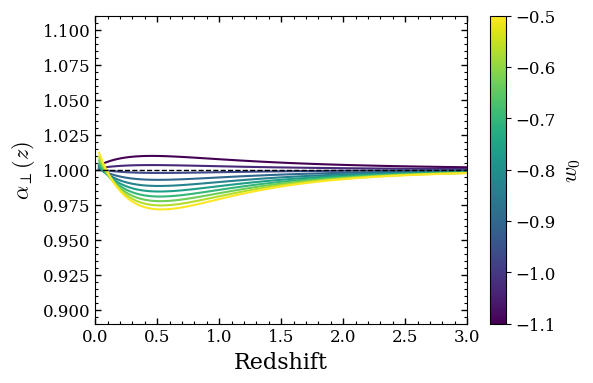

In [17]:
# define colormap and normalisation
cmap = cm.viridis  # or any other: viridis, plasma, RdBu, etc.
norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

fig, ax = plt.subplots(figsize=(6, 4))

print(len(w0))
mask = 20
for i in range(len(w0[:mask])):
    ax.plot(z, alph_perp[i], color=cmap(norm(w0[i])))

# colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$w_0$')

ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\perp(z)$')
plt.axhline(1, color='k', ls='--', lw=1)
plt.xlim(0, 3)
plt.ylim(0.89, 1.11)

10


(0.89, 1.11)

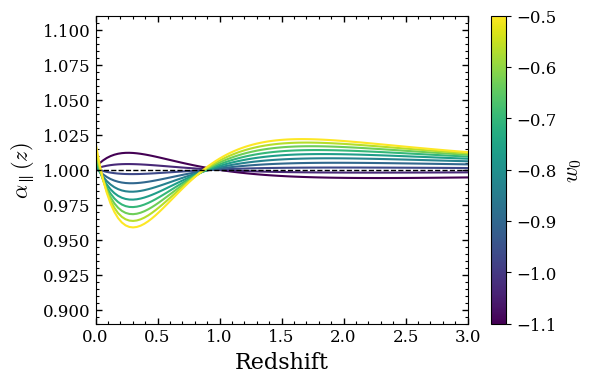

In [18]:
# define colormap and normalisation
cmap = cm.viridis  # or any other: viridis, plasma, RdBu, etc.
norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

fig, ax = plt.subplots(figsize=(6, 4))

print(len(w0))
mask = 20
for i in range(len(w0[:mask])):
    # a_perp_inv = [1/val for val in alph_perp[i]]
    ax.plot(z, alph_par[i], color=cmap(norm(w0[i])))
    # ax.plot(z, a_perp_inv, color=cmap(norm(w0[i])))

# colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$w_0$')

ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\parallel(z)$')
plt.axhline(1, color='k', ls='--', lw=1)
plt.xlim(0, 3)
plt.ylim(0.89, 1.11)

#### for different lines

In [19]:
def get_DESI_errors():
    dict_distance, z_DESI, path = get_DESI_data()

    cov_mat = np.loadtxt(path.replace('mean', 'cov'))

    errors = {}
    for i in range(len(cov_mat[0, :])):
        z = z_DESI[i//2]
        if i == 0:
            _, _, DVfid = get_DESI_fid(z)
            a_iso_err = np.sqrt(cov_mat[i][i]) / DVfid
            errors[z] = {'d_iso': a_iso_err}
        elif i%2 == 0:
            cov = [[cov_mat[i-1, i-1], cov_mat[i-1, i]], [cov_mat[i, i-1], cov_mat[i, i]]]
            sig_x = np.sqrt(cov[0][0])
            sig_y = np.sqrt(cov[1][1])

            DMfid, DHfid, DVfid = get_DESI_fid(z)
            if i == len(cov_mat[0, :])-1:
                d_a_perp = sig_y / DMfid
                d_a_par = sig_x / DHfid                
            else :
                d_a_perp = sig_x / DMfid
                d_a_par = sig_y / DHfid

            DM = dict_distance[z]['DM_over_rs']
            DH = dict_distance[z]['DH_over_rs']
            DV = (z*DM**2*DH)**(1/3)

            a_perp = DM / DMfid
            a_par = DH / DHfid
            a_iso = DV / DVfid
            a_AP = a_par / a_perp

            d_a_AP = a_AP * np.sqrt((d_a_par / a_par)**2 + (d_a_perp / a_perp)**2)
            d_a_iso = a_iso * np.sqrt((2/3)**3 * (d_a_perp / a_perp)**2 + (1/3)**2 * (d_a_par / a_par)**2)

            errors[z] = {'d_perp':  d_a_perp,
                         'd_par':   d_a_par,
                         'd_AP':    d_a_AP,
                         'd_iso':   d_a_iso
                         }
    return errors, z_DESI

def get_DESI_data():
    z_DESI = []
    path = r'..\..\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_mean.txt'
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z_DESI.append(float(parts[0]))

    z_DESI = set(z_DESI)
    z_DESI = list(z_DESI)
    z_DESI.sort()
    dict_distance = {}
    for z in z_DESI:
        dict_distance[z] = {}

    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z = float(parts[0])
            for key in dict_distance.keys():
                if key == z:
                    dict_distance[key][parts[2]] = float(parts[1])
    
    return dict_distance, z_DESI, path

def get_DESI_fid(redshift):
    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(redshift)
    DH_fid = 1 / DESI_bkg.efunc(redshift) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (redshift * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    return DMover_rd_fid, DHover_rd_fid, DVover_rd_fid

In [ ]:
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_alpha_ratios(redshift, slope, offset, param_cosmo, ylim=None, yticks=None, text_loc='lower right', 
                      name='', path_save=None, xlabel=True, show_plots=True, DESI_errors=None,
                      envelope_settings=None, symmetric=False):
    
    alph_perp = []
    alph_par  = []
    alph_AP   = []
    alph_ISO  = []

    w0 = [cosmo[0] for cosmo in param_cosmo]

    for i in range(len(w0)):
        a, b, c = alpha_perp_parallel(redshift, param_cosmo[i])
        alph_perp.append(a)
        alph_par.append(b)
        alph_AP.append(b / a)
        alph_ISO.append(c)

    cmap = cm.viridis
    w0min, w0max = min(w0), max(w0)

    if symmetric:
        if w0max < -0.8: w0max = -0.8
        if w0min > -1.2: w0min = -1.2
    else:
        if w0max < -0.5: w0max = -0.5
        if w0min > -1.1: w0min = -1.1

    norm = mcolors.Normalize(vmin=w0min, vmax=w0max)

    fig = plt.figure(figsize=(10, 7))
    gs = fig.add_gridspec(
            2, 2,
        wspace=0.32, hspace=0.3
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    axes = {'00': ax00, '01': ax01, '10': ax10, '11': ax11}
    data = {'00': alph_ISO, '01': alph_AP, '10': alph_perp, '11': alph_par}
    ylabels = {
        '00': r'$\alpha_\mathrm{ISO}(z)$',
        '01': r'$\alpha_\mathrm{AP}(z)$',
        '10': r'$\alpha_\perp(z)$',
        '11': r'$\alpha_\parallel(z)$',
    }

        # if envelope_settings is not None:
        #     envelope_type = envelope_settings['type']
        #     if envelope_type == 'spline':
        #         a = envelope_settings['alpha']
        #         k = envelope_settings['k']
        #         smooth = envelope_settings['smooth']
        #         from scipy.interpolate import UnivariateSpline
        #         z_fine = np.linspace(0, 3, 200)
        #         spline = UnivariateSpline(z_DESI_uncert, a_perp_err, s=smooth, k=k)  # s contrôle le lissage
        #         ax10.fill_between(z_fine, 1 - spline(z_fine), 1 + spline(z_fine), color='k', alpha=a)
        
        # from scipy.interpolate import interp1d

        # z_fine = np.linspace(min(z_DESI_uncert), max(z_DESI_uncert), 200)
        # z_fine = np.linspace(0, 3, 200)
        # err_interp = interp1d(z_DESI_uncert, a_perp_err, kind='cubic', fill_value='extrapolate')
        # ax10.fill_between(z_fine, 1 - err_interp(z_fine), 1 + err_interp(z_fine), color='k', alpha=0.2)

    if DESI_errors is not None:
        uncert, z_uncert = get_DESI_errors()
        a_perp_err = []
        a_par_err = []
        a_iso_err = []
        a_AP_err = []
        for idx, (_, value) in enumerate(uncert.items()):
            if idx == 0:
                a_iso_err.append(value['d_iso'])
            else:
                a_perp_err.append(value['d_perp'])
                a_par_err.append(value['d_par'])
                a_AP_err.append(value['d_AP'])
                a_iso_err.append(value['d_iso'])
        a_err = [a_iso_err, a_AP_err, a_perp_err, a_par_err]

    for idx, (key, ax) in enumerate(axes.items()):
        for i in range(len(w0)):
            ax.plot(redshift, data[key][i], color=cmap(norm(w0[i])))
    
        if DESI_errors is not None:
            if idx == 0:
                ax.errorbar(z_uncert, [1 for _ in z_uncert], yerr=a_err[idx], fmt='o', color='k', markersize=3)
            else:
                ax.errorbar(z_uncert[1:], [1 for _ in z_uncert[1:]], yerr=a_err[idx], fmt='o', color='k', markersize=3)

        ax.axhline(1, color='k', ls='--', lw=1)

        ax.tick_params(which='major', direction='in', length=4, width=1,   top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.set_ylabel(ylabels[key], fontsize=18)
        ax.set_xlim(0, 3)

        if ylim is not None:
            if 'all' in ylim:
                ax.set_ylim(ylim['all'])
            elif key in ylim:
                ax.set_ylim(ylim[key])

        if yticks is not None:
            if 'all' in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks['all']))
            elif key in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks[key]))

        if xlabel and key in ('10', '11'):
            ax.set_xlabel('Redshift', fontsize=16)

    leg_txt = rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$'
    if slope == 0.0: leg_txt = rf'$w_a = 0$'
    text = AnchoredText(
        leg_txt,
        loc=text_loc, frameon=True, prop=dict(size=14)
    )
    axes['00'].add_artist(text)

    # --- Colorbar à droite, taille ~1 subplot, centrée ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$w_0$', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    if path_save is not None:
        slope_str  = f'{slope:.2f}'
        offset_str = f'{offset:.1f}'
        
        if not xlabel:
            folder = r'\no_xlabel'
            pth_folder =  path_save + folder
            os.makedirs(pth_folder, exist_ok=True)
            fname = folder + rf'\{name}_{slope_str}_{offset_str}' if name else rf'{slope_str}_{offset_str}'
        else:
            fname = f'{name}_{slope_str}_{offset_str}' if name else f'{slope_str}_{offset_str}'

        if path_save is None:
            path_save = rf'..\..\figures\degen_line\alpha_ratio\final\{fname}.png'
        else:
            path_save= path_save + f'\{fname}.png'
        fig.savefig(
            path_save,
            dpi=150, bbox_inches='tight'
        )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

<string>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1733381929.py:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  path_save= path_save + f'\{fname}.png'


In [21]:
def plot_alpha_ratios_2panels(redshift, slope, offset, param_cosmo, ylim=None, yticks=None, text_loc='lower right', 
                                name='', path_save=None, xlabel=True, show_plots=True, DESI_errors=None,
                                envelope_settings=None, symmetric=False, AP_ISO = True):
    
    if AP_ISO:
        alph_AP   = []
        alph_ISO  = []
    else:
        alph_perp = []
        alph_par  = []

    w0 = [cosmo[0] for cosmo in param_cosmo]

    for i in range(len(w0)):
        a, b, c = alpha_perp_parallel(redshift, param_cosmo[i])
        if AP_ISO:
            alph_AP.append(b / a)
            alph_ISO.append(c)
        else:
            alph_perp.append(a)
            alph_par.append(b)

    cmap = cm.viridis
    w0min, w0max = min(w0), max(w0)

    if symmetric:
        if w0max < -0.8: w0max = -0.8
        if w0min > -1.2: w0min = -1.2
    else:
        if w0max < -0.5: w0max = -0.5
        if w0min > -1.1: w0min = -1.1

    norm = mcolors.Normalize(vmin=w0min, vmax=w0max)

    fig = plt.figure(figsize=(10, 3.5))
    gs = fig.add_gridspec(
            1, 2,
        wspace=0.32, hspace=0.3
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])

    axes = {'00': ax00, '01': ax01}
    if AP_ISO:
        data = {'00': alph_ISO, '01': alph_AP}
        ylabels = {
            '00': r'$\alpha_\mathrm{ISO}(z)$',
            '01': r'$\alpha_\mathrm{AP}(z)$'
            }        
    else:
        data = {'00': alph_perp, '01': alph_par}
        ylabels = {
            '00': r'$\alpha_\perp(z)$',
            '01': r'$\alpha_\parallel(z)$'
            }


        # if envelope_settings is not None:
        #     envelope_type = envelope_settings['type']
        #     if envelope_type == 'spline':
        #         a = envelope_settings['alpha']
        #         k = envelope_settings['k']
        #         smooth = envelope_settings['smooth']
        #         from scipy.interpolate import UnivariateSpline
        #         z_fine = np.linspace(0, 3, 200)
        #         spline = UnivariateSpline(z_DESI_uncert, a_perp_err, s=smooth, k=k)  # s contrôle le lissage
        #         ax10.fill_between(z_fine, 1 - spline(z_fine), 1 + spline(z_fine), color='k', alpha=a)
        
        # from scipy.interpolate import interp1d

        # z_fine = np.linspace(min(z_DESI_uncert), max(z_DESI_uncert), 200)
        # z_fine = np.linspace(0, 3, 200)
        # err_interp = interp1d(z_DESI_uncert, a_perp_err, kind='cubic', fill_value='extrapolate')
        # ax10.fill_between(z_fine, 1 - err_interp(z_fine), 1 + err_interp(z_fine), color='k', alpha=0.2)
    
    if DESI_errors is not None:
        uncert, z_uncert = get_DESI_errors()
        a_perp_err = []
        a_par_err = []
        a_iso_err = []
        a_AP_err = []
        for idx, (_, value) in enumerate(uncert.items()):
            if idx == 0:
                a_iso_err.append(value['d_iso'])
            else:
                a_perp_err.append(value['d_perp'])
                a_par_err.append(value['d_par'])
                a_AP_err.append(value['d_AP'])
                a_iso_err.append(value['d_iso'])
        a_err = [a_iso_err, a_AP_err, a_perp_err, a_par_err]
    
    if AP_ISO:
        a_err = a_err[:2]
    else:
        a_err = a_err[2:]

    for idx, (key, ax) in enumerate(axes.items()):
        for i in range(len(w0)):
            ax.plot(redshift, data[key][i], color=cmap(norm(w0[i])))
    
        if DESI_errors is not None:
            if idx == 0 and AP_ISO:
                ax.errorbar(z_uncert, [1 for _ in z_uncert], yerr=a_err[idx], fmt='o', color='k', markersize=3)
            else:
                ax.errorbar(z_uncert[1:], [1 for _ in z_uncert[1:]], yerr=a_err[idx], fmt='o', color='k', markersize=3)

        ax.axhline(1, color='k', ls='--', lw=1)

        ax.tick_params(which='major', direction='in', length=4, width=1,   top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.set_ylabel(ylabels[key], fontsize=18)
        ax.set_xlim(0, 3)

        if ylim is not None:
            if 'all' in ylim:
                ax.set_ylim(ylim['all'])
            elif key in ylim:
                ax.set_ylim(ylim[key])

        if yticks is not None:
            if 'all' in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks['all']))
            elif key in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks[key]))

        if xlabel and key in ('00', '01'):
            ax.set_xlabel('Redshift', fontsize=16)

    leg_txt = rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$'
    if slope == 0.0: leg_txt = rf'$w_a = 0$'
    text = AnchoredText(
        leg_txt,
        loc=text_loc, frameon=True, prop=dict(size=14)
    )
    axes['00'].add_artist(text)

    # --- Colorbar à droite, taille ~1 subplot, centrée ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.74])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$w_0$', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    if path_save is not None:
        slope_str  = f'{slope:.2f}'
        offset_str = f'{offset:.1f}'
        
        if not xlabel:
            folder = r'\no_xlabel'
            pth_folder =  path_save + folder
            os.makedirs(pth_folder, exist_ok=True)
            fname = folder + rf'\{name}_{slope_str}_{offset_str}' if name else rf'{slope_str}_{offset_str}'
        else:
            fname = f'{name}_{slope_str}_{offset_str}' if name else f'{slope_str}_{offset_str}'

        if path_save is None:
            path_save = rf'..\..\figures\degen_line\alpha_ratio\final\{fname}.png'
        else:
            path_save= path_save + f'\{fname}.png'
        fig.savefig(
            path_save,
            dpi=150, bbox_inches='tight'
        )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

<string>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\3596661773.py:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  path_save= path_save + f'\{fname}.png'


In [22]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1.1, -0.5, 10)
offset = 1
slope = -3.66
wa = slope * ( w0 + offset)
Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
param_mirage = list(zip(w0, wa, Omega_m, hrdrag))

In [23]:
# # plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.1)}, yticks={'all': 0.05}, name='mirage')
# spline_settings = {'type': 'spline', 'alpha': 0.3, 'k': 2, 'smooth': 3}
# plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.11)}, #yticks={'all': 0.05}, name='mirage',
#                     DESI_errors=get_DESI_errors(), envelope_settings=spline_settings)

In [24]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1.2, -0.8, 10)
offset = 1
slope = -3.66
wa = slope * ( w0 + offset)
Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
param_mirage_sym = list(zip(w0, wa, Omega_m, hrdrag))

In [25]:
# plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.1)}, yticks={'all': 0.05}, name='mirage')
spline_settings = {'type': 'spline', 'alpha': 0.3, 'k': 2, 'smooth': 3}
# plot_alpha_ratios(z, slope, offset, param_mirage_sym, ylim={'all': (0.89, 1.11)}, #yticks={'all': 0.05}, name='mirage',
#                     DESI_errors=get_DESI_errors(), envelope_settings=spline_settings)

#### imitate Fig 13

In [26]:
# from matplotlib.offsetbox import AnchoredText

# alph_perp = []
# alph_par = []
# alph_AP = []
# alph_ISO = []

# z = np.linspace(0.0, 3.0, 1000)

# w0 = mean_w
# wa = mean_wa
# obh2 = mean_ombh2
# och2 = mean_omch2
# h = mean_H0/100
# hrdrag = mean_rdrag*h

# print(f"w0: {w0:.2f}, wa: {wa:.2f}, obh2: {obh2:.5f}, och2: {och2:.5f}, h: {h:.3f}, hrdrag: {hrdrag:.2f}")
# # Omegam = slopes[1] * w0[i] + intercepts[1]
# # hrdrag = slopes[2] * w0[i] + intercepts[2]
# a, b, c = alpha_perp_parallel_alt(z, (w0, wa, obh2, och2, h, hrdrag))
# alph_perp.append(a)
# alph_par.append(b)
# alph_AP.append(b/a)
# alph_ISO.append(c)

# w0 = -1.0
# wa = 0.0
# obh2 =  mean_ombh2_2
# och2 = mean_omch2_2
# h = mean_H0_2/100
# hrdrag = mean_rdrag_2*h
# a, b, c = alpha_perp_parallel_alt(z, (w0, wa, obh2, och2, h, hrdrag))
# alph_perp.append(a)
# alph_par.append(b)
# alph_AP.append(b/a)
# alph_ISO.append(c)


# # for DESY5 we only have omega_m and we'll set a value of hrdrag
# fid_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
# fid_bkg = fid_planck.get_background(engine='camb')
# fid_thermo = fid_planck.get_thermodynamics()
# rdrag_fid = fid_thermo.rs_drag
# DM_fid = fid_bkg.comoving_angular_distance(z)
# DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
# DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
# DMover_rd_fid = DM_fid / rdrag_fid
# DHover_rd_fid = DH_fid / rdrag_fid
# DVover_rd_fid = DV_fid / rdrag_fid
# w0 = -1.0
# wa = 0.0
# omm =  mean_omm_3
# DM_desy5 = trans_comoving_dist_array(z, [omm, w0, wa])
# DH_desy5 = Hubble_dist(z, [omm, w0, wa])
# DV_desy5 = [compute_DV(red, [omm, w0, wa]) for red in z]
# rdrag_fid = 98.1
# DMover_rd_desy5 = [d / rdrag_fid for d in DM_desy5]
# DHover_rd_desy5 = [d / rdrag_fid for d in DH_desy5]
# DVover_rd_desy5 = [d / rdrag_fid for d in DV_desy5]
# alph_perp.append(DMover_rd_desy5 / DMover_rd_fid)
# alph_par.append(DHover_rd_desy5 / DHover_rd_fid)
# alph_ISO.append(DVover_rd_desy5 / DVover_rd_fid)

In [27]:
# # subplots
# fig, axes = plt.subplots(1, 3,figsize=(18, 4))

# xlimits = [(0.05, 3) for _ in range(3)]

# ############ fig 1 alpha ISO #################
# axes[0].plot(z, alph_ISO[0], color='r', ls='--', label=r'$w_0 w_a \mathrm{CDM}$: '+'DESI+CMB+DESY5')
# axes[0].plot(z, alph_ISO[1], color='purple', ls='-', label=r'$\Lambda \mathrm{CDM}:$ DESI'+'+CMB')
# axes[0].plot(z, alph_ISO[2], color='darkorange', ls='-')

# axes[0].set_xscale('log')

# axes[0].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
# axes[0].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
# axes[0].xaxis.set_minor_locator(AutoMinorLocator())
# axes[0].yaxis.set_minor_locator(AutoMinorLocator(2))
# axes[0].set_xticks([0.02, 0.1, 0.5, 1, 3])
# axes[0].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

# axes[0].set_ylim(0.94, 1.04)
# axes[0].set_xlim(xlimits[0])

# axes[0].set_xlabel('Redshift', fontsize=16)
# axes[0].set_ylabel(r'$\alpha_\mathrm{ISO}(z)$', fontsize=16)
# axes[0].axhline(1, color='k', ls='-', lw=2)
# axes[0].legend(loc='lower left', fontsize=12)

# ############ fig 2 alpha perp #################
# axes[1].plot(z, alph_perp[0], color='r', ls='--')
# axes[1].plot(z, alph_perp[1], color='purple', ls='-')
# axes[1].plot(z, alph_perp[2], color='darkorange', ls='-', label=r'$\Lambda \mathrm{CDM}$: '+'DESY5')

# axes[1].set_xscale('log')

# axes[1].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
# axes[1].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
# axes[1].xaxis.set_minor_locator(AutoMinorLocator())
# axes[1].yaxis.set_minor_locator(AutoMinorLocator(2))
# axes[1].set_xticks([0.02, 0.1, 0.5, 1, 3])
# axes[1].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

# axes[1].set_ylim(0.94, 1.04)
# axes[1].set_xlim(xlimits[1])

# axes[1].set_xlabel('Redshift', fontsize=16)
# axes[1].set_ylabel(r'$\alpha_\perp(z)$', fontsize=16)
# axes[1].axhline(1, color='k', ls='-', lw=2)
# axes[1].legend(loc='lower left', fontsize=12)

# # ############ fig 3 alpha parallel #################
# axes[2].plot(z, alph_par[0], ls='--', color='r')
# axes[2].plot(z, alph_par[1], color='purple', ls='-')
# axes[2].plot(z, alph_par[2], color='darkorange', ls='-')

# axes[2].set_xscale('log')

# axes[2].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
# axes[2].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
# axes[2].xaxis.set_minor_locator(AutoMinorLocator())
# axes[2].yaxis.set_minor_locator(AutoMinorLocator(2))
# axes[2].set_xticks([0.02, 0.1, 0.5, 1, 3])
# axes[2].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

# axes[2].set_ylim(0.94, 1.04)
# axes[2].set_xlim(xlimits[2])

# axes[2].set_xlabel('Redshift', fontsize=16)
# axes[2].set_ylabel(r'$\alpha_\parallel(z)$', fontsize=16)
# axes[2].axhline(1, color='k', ls='-', lw=2)

# # plt.savefig(r'..\..\figures\degen_line\alpha_ratio\paper_comparison.png', dpi=300, bbox_inches='tight')

## other lines

In [28]:
lines = {
    'mirage': (-3.66, 1.0),
    'par': (-3.66, 0.8),
    'par_closer': (-3.66, 0.9),
    'perp':     (3.66, 1.0),
    'NEC':      (-1.0, 1.0),
    'steep':    (-4.5, 1.0),
    'steeper':    (-6.0, 1.0)
}

In [29]:
lines_param = {}
for name, (slope, offset) in lines.items():
    w0_max = -0.5
    if slope+1 > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        w0_max *= 1.01
        w0_max = min(w0_max, -0.5)
    w0 = np.linspace(-1.1, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param[name] = param_cosmo

In [30]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, name=name, 
#                       DESI_errors=DESI_errors)#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, xlabel=False, name=name, save=True, show_plots=False)

In [32]:
z = np.linspace(0.0, 3.0, 100)
# for name, (slope, offset) in lines.items():
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, name=name)#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, xlabel=False, name=name, save=True, show_plots=False)

In [33]:
lines_param_fixed_Om_hrdrag = {}
for name, (slope, offset) in lines.items():
    w0_max = -0.5
    if abs(slope+1) > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        w0_max *= 1.01
        w0_max = min(w0_max, -0.5)
    w0 = np.linspace(-1.1, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m, hrdrag = 0.3, 100
    Omega_m = np.full_like(w0, Omega_m)
    hrdrag = np.full_like(w0, hrdrag)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_fixed_Om_hrdrag[name] = param_cosmo

In [35]:
z = np.linspace(0.0, 3.0, 100)
# for name, (slope, offset) in lines.items():
    # plot_alpha_ratios(z, slope, offset, lines_param_fixed_Om_hrdrag[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   name=name, method_Om_hrdrag='fixed_Om_hrdrag', text_loc='upper right')#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param_fixed_Om_hrdrag[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   xlabel=False, name=name, method_Om_hrdrag='fixed_Om_hrdrag', text_loc='upper right', save=True, show_plots=False)

## symmetric plots

alpha plots pour un domaine symmétrique autour de -1 : -1.2 à -0.8
Toutes les lignes fonctionnent sauf la parallèle avec offset 0.8 qui doit commencer à -1.1

In [41]:
lines = {
    'mirage': (-3.66, 1.0),
    'par': (-3.66, 0.9),
    'par2':    (-3.66, 1.1),
    'flat': (0.0, 0.9),
    'perp':     (3.66, 1.0),
    'NEC':      (-1.0, 1.0),
    'steeper':    (-6.0, 1.0)
}

lines = {
    'mirage': (-3.66, 1.0),
    'par2': (-3.66, 1.1),
    'par3':    (-3.66, 1.2)
}

In [42]:
lines_param_sym = {}
lines_param_sym_fixed = {}
for name, (slope, offset) in lines.items():     
    w0_max = -0.8
    if abs(slope+1) > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        # print(f"line: {name}, w0_max: {w0_max:.2f}")
        if (w0_max < -0.8) and (w0_max > -1.2):
             if slope < 0:
                 w0_min = w0_max
                 w0_max = -0.8
             else:
                 w0_min = -1.2
                 w0_max = w0_max
        else:
             w0_max = -0.8
             w0_min = -1.2

    w0 = np.linspace(w0_min, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m = np.full_like(w0, 0.3)
    hrdrag = np.full_like(w0, 100)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_sym_fixed[name] = param_cosmo
    Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_sym[name] = param_cosmo

C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


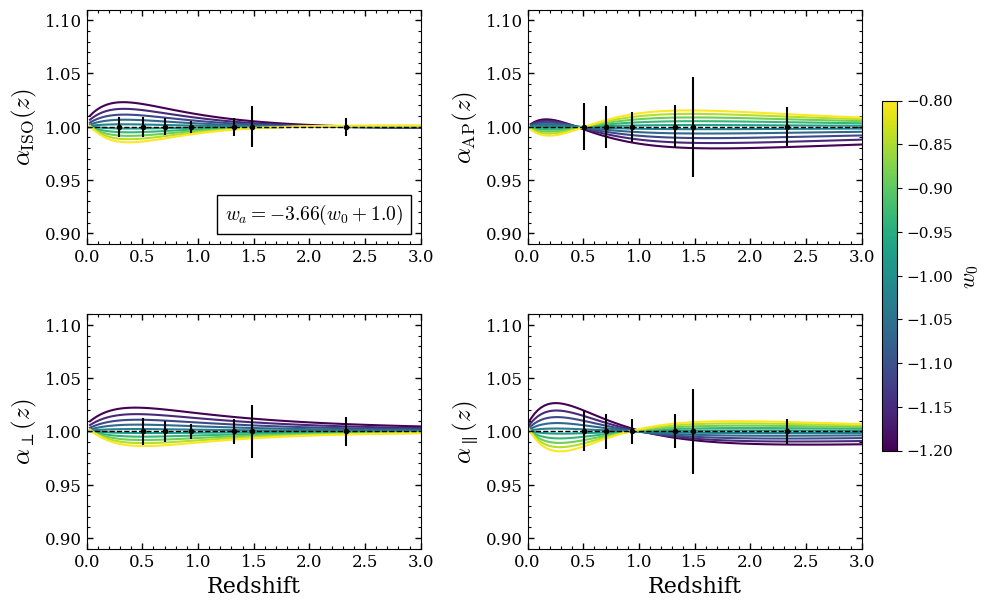

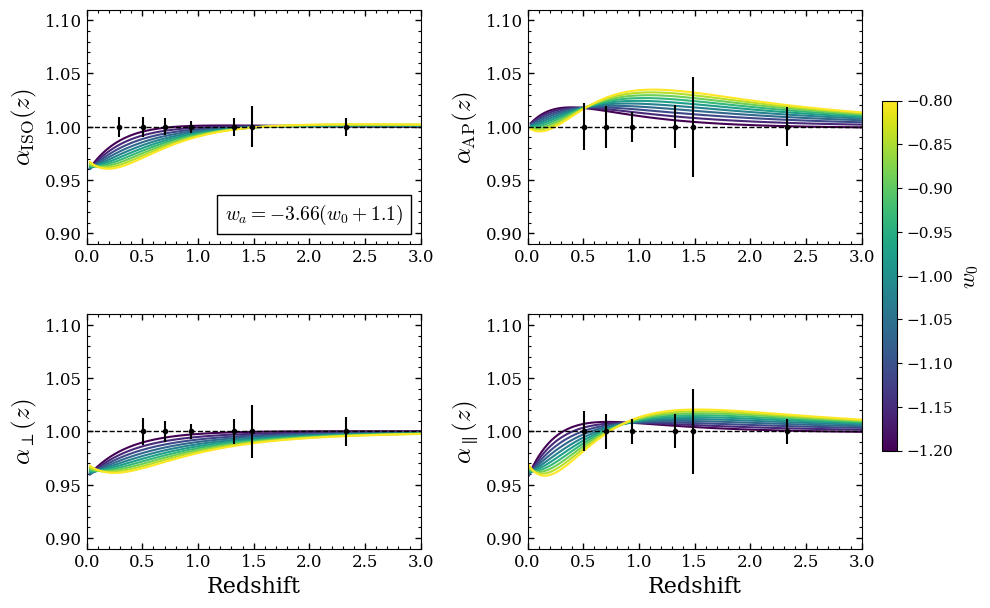

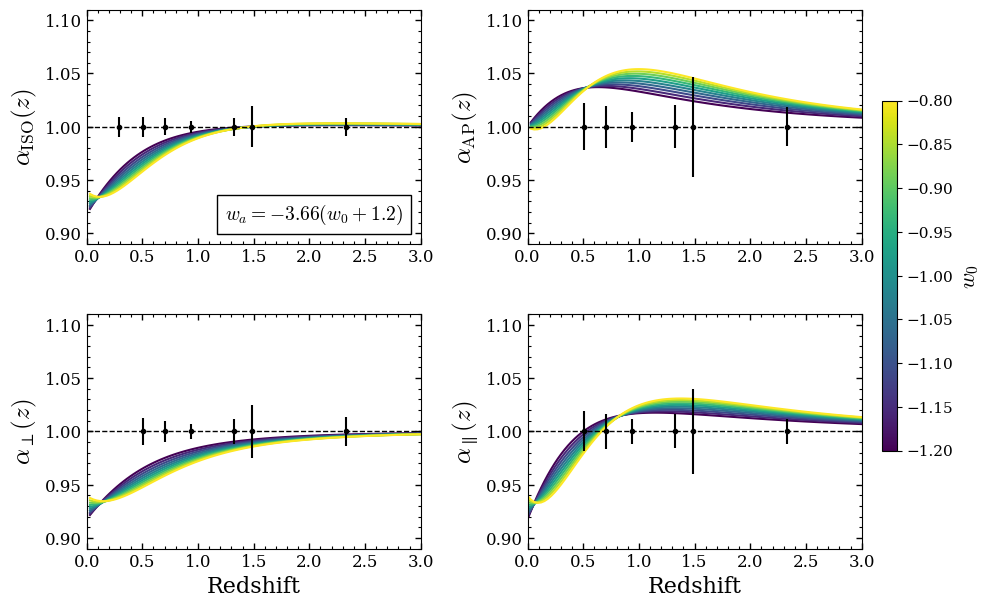

In [43]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\4plots\symmetric\Om_hrdrag_free'

for name, (slope, offset) in lines.items():
    plot_alpha_ratios(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, name=name, 
                    DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                       DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

In [ ]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\4plots\symmetric\Om_hrdrag_fixed'

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, name=name, 
#                     DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                       DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


### 2 panels

C:\Users\adrie\AppData\Local\Temp\ipykernel_46704\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


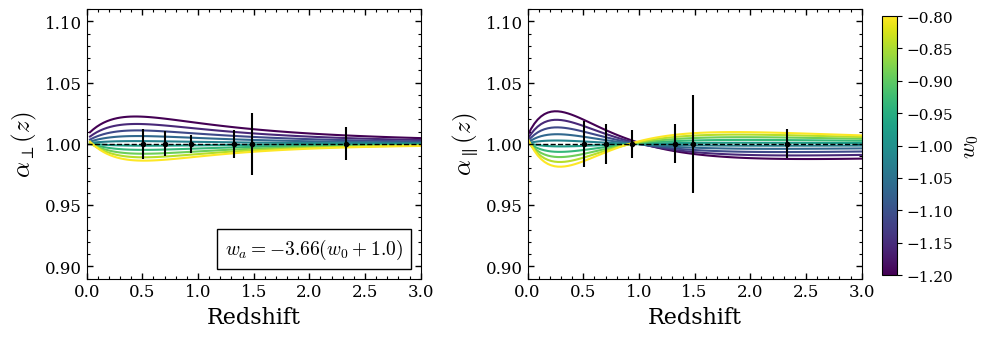

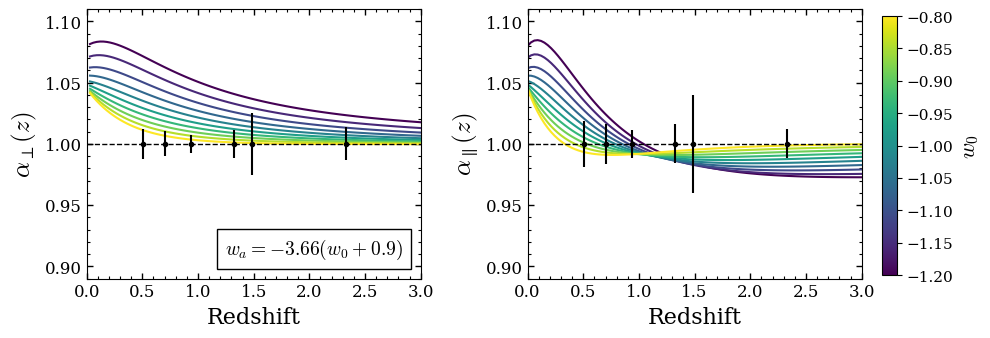

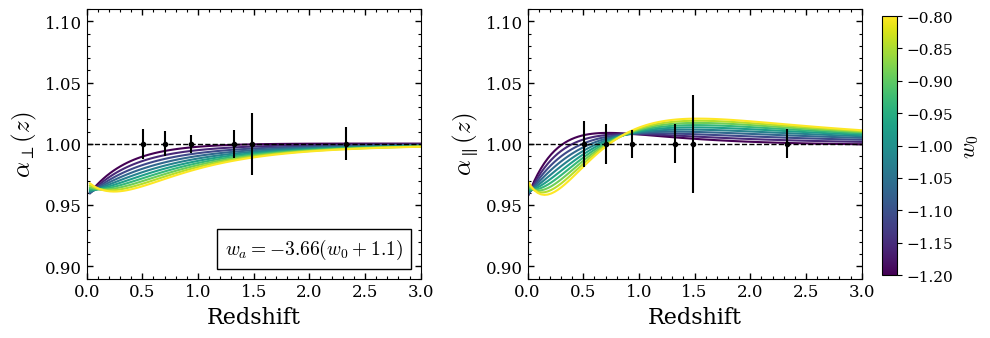

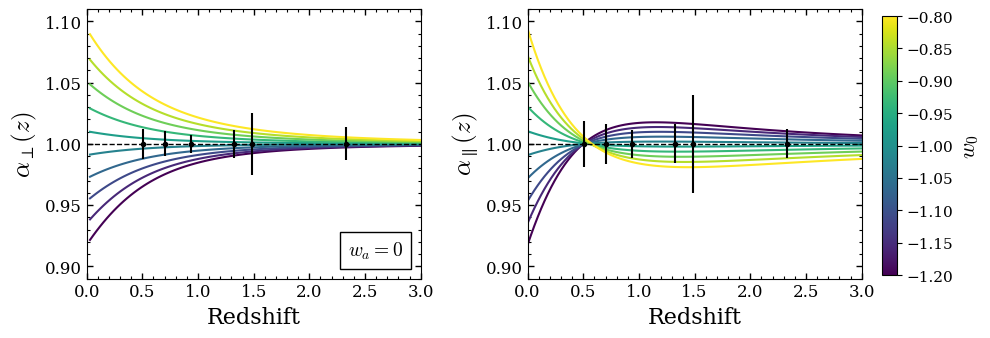

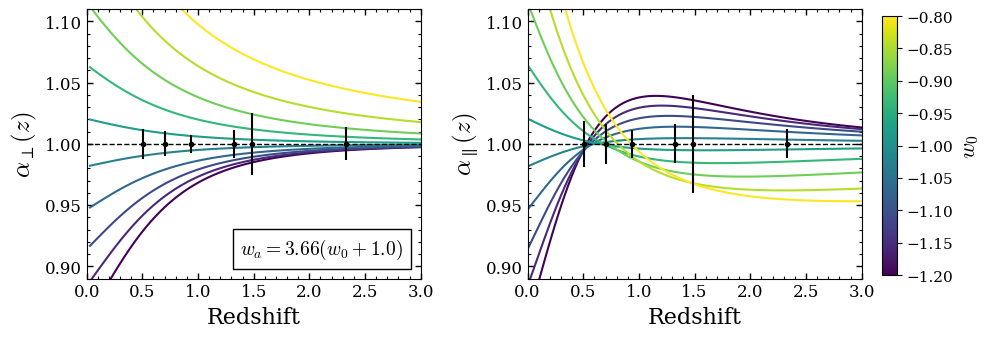

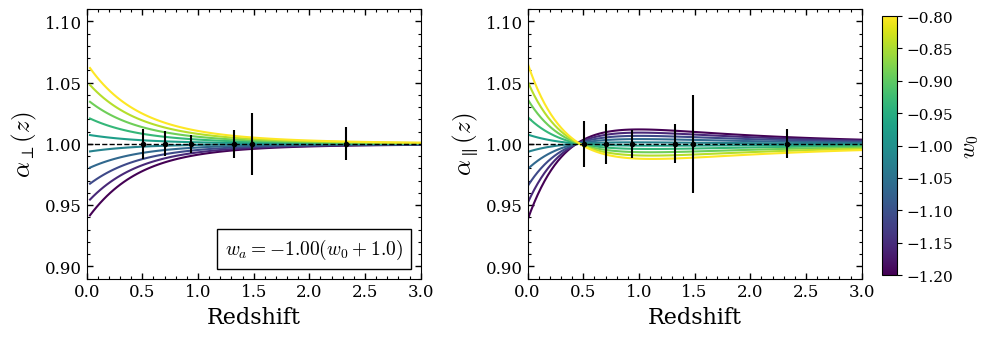

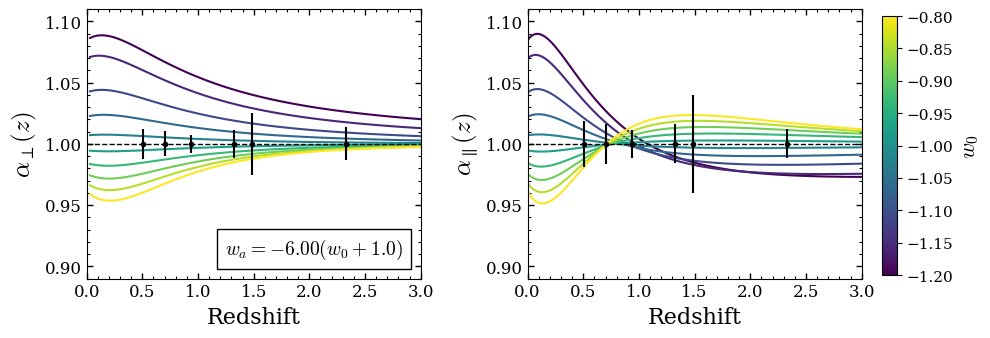

In [26]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\2plots\symmetric\Om_hrdrag_free'

for name, (slope, offset) in lines.items():
    plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, name=name, 
                                DESI_errors=DESI_errors, symmetric=True, AP_ISO=False)#, path_save=path, show_plots=False)
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

In [ ]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\2plots\symmetric\Om_hrdrag_fixed'

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

C:\Users\adrie\AppData\Local\Temp\ipykernel_45612\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


# ideas

In [ ]:
path_BAOall = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all\chain'
gd_sample_BAOall = load_samples(path_BAOall, to_getdist=True, skip=0.33)

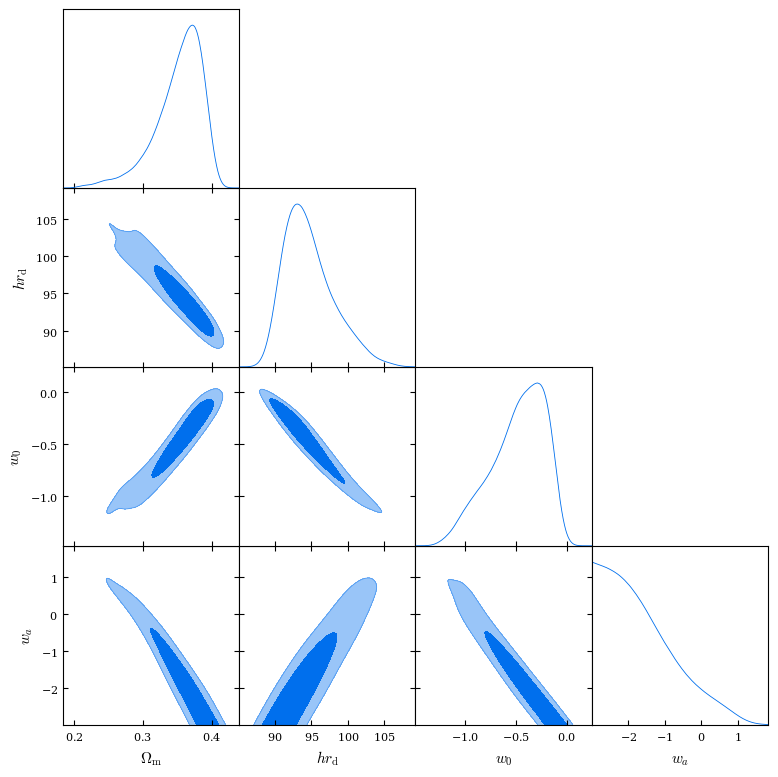

In [13]:
var_names = ['omegam', 'hrdrag', 'w', 'wa']
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample_BAOall, var_names, filled=True)

In [9]:
params = gd_sample_BAOall.getParams()
w0_samples      = params.w
wa_samples      = params.wa
Omega_m_samples = params.omm
hrdrag_samples  = params.hrdrag

weights = gd_sample_BAOall.weights

coeffs_Om    = np.polyfit(w0_samples, Omega_m_samples, 1, w=weights)
coeffs_hrdrag = np.polyfit(w0_samples, hrdrag_samples,  1, w=weights)

w0_line = np.linspace(-1.1, -0.5, 100)
Omega_m_on_line  = np.polyval(coeffs_Om,     w0_line)
hrdrag_on_line   = np.polyval(coeffs_hrdrag, w0_line)

In [15]:
print(coeffs_Om)

[0.12494807 0.41109128]


In [47]:
# w0_plot = np.linspace(-3, 1, 10)
# gdplot = gdplt.get_single_plotter()
# gdplot.plot_2d(gd_sample_BAOall, 'w', 'omegam', filled=True)
# plt.plot(w0_plot, coeffs_Om[0] * w0_plot + coeffs_Om[1], color='r', ls='--')
# yfill = [0, 1]
# plt.fill_betweenx(yfill, -1.1, -0.5, color='gray', alpha=0.5)
# yfill = [np.polyval(coeffs_Om, -1.1), np.polyval(coeffs_Om, -0.5)]
# plt.fill_between([-2, -0.5], yfill[0], yfill[1], color='g', alpha=0.3)
# plt.yticks([0.2, yfill[0], 0.3, yfill[1], 0.4], labels=['0.2', f'{yfill[0]:.3f}', '0.3', f'{yfill[1]:.3f}', '0.4'])
# plt.xlabel(r'$w_0$', fontsize=16)
# plt.ylabel(r'$\Omega_m$', fontsize=16)

# gdplot = gdplt.get_single_plotter()
# gdplot.plot_2d(gd_sample_BAOall, 'w', 'hrdrag', filled=True)
# plt.plot(w0_plot, coeffs_hrdrag[0] * w0_plot + coeffs_hrdrag[1], color='r', ls='--')
# yfill = [80, 120]
# plt.fill_betweenx(yfill, -1.1, -0.5, color='gray', alpha=0.5)
# yfill = [np.polyval(coeffs_hrdrag, -1.1), np.polyval(coeffs_hrdrag, -0.5)]
# plt.fill_between([-2, -0.5], yfill[0], yfill[1], color='g', alpha=0.3)
# plt.yticks([90, 95, 100, yfill[0], 105], labels=['90', '95', '100', f'{yfill[0]:.1f}', '105'])
# plt.xlabel(r'$w_0$', fontsize=16)
# plt.ylabel(r'$h r_\mathrm{drag}$', fontsize=16)

In [21]:
lines_param_baoall_Omm_hrd = {}
for name, (slope, offset) in lines.items():
    w0_max = -0.5
    if slope+1 > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        w0_max *= 1.01
        w0_max = min(w0_max, -0.5)
    w0 = np.linspace(-1.1, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m  = np.polyval(coeffs_Om,     w0)
    hrdrag   = np.polyval(coeffs_hrdrag, w0)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_baoall_Omm_hrd[name] = param_cosmo

In [ ]:
# z = np.linspace(0.0, 3.0, 100)
# for name, (slope, offset) in lines.items():
    # plot_alpha_ratios(z, slope, offset, lines_param_baoall_Omm_hrd[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   name=name, method_Om_hrdrag='BAOall_Om_hrdrag', text_loc='upper right')#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param_baoall_Omm_hrd[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   xlabel=False, name=name, method_Om_hrdrag='BAOall_Om_hrdrag', text_loc='upper right')#, save=True, show_plots=False)

C:\Users\adrie\AppData\Local\Temp\ipykernel_25528\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
